# 01 — Dataset exploration

Verify dataset paths, image counts, annotations, and masks. FishNet images use **uppercase `.JPG`** extensions.


In [9]:
import logging
import random
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "src").is_dir() else ROOT.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from src.config import get_config
from src.dataset import build_split_index, discover_image_paths, iterate_dataset, load_sample
from src.masks import mask_from_class
from src.measurement import measure_bbox_length, measure_pca_length
from src.utils import setup_logging
from src.visualization import (
    display_sample,
    draw_polygon_annotations,
    overlay_masks,
    plot_pca_axis,
    save_figure,
)

setup_logging(level=logging.INFO)
cfg = get_config()

print("Dataset root:", cfg.resolve_dataset_root())
for split in ("train", "valid", "test"):
    n = len(discover_image_paths(cfg, split))
    print(f"  {split}: {n} images")


Dataset root: /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet
2026-05-29 20:48:20 | INFO     | src.dataset | Found 557 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/train (train)
  train: 557 images
2026-05-29 20:48:20 | INFO     | src.dataset | Found 105 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/valid (valid)
  valid: 105 images
2026-05-29 20:48:20 | INFO     | src.dataset | Found 35 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/test (test)
  test: 35 images


In [10]:
index = build_split_index(cfg)
for split, ids in index.items():
    print(f"{split}: {len(ids)} images")


2026-05-29 20:48:25 | INFO     | src.dataset | Found 557 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/train (train)
2026-05-29 20:48:25 | INFO     | src.dataset | Found 105 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/valid (valid)
2026-05-29 20:48:25 | INFO     | src.dataset | Found 35 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/test (test)
train: 557 images
valid: 105 images
test: 35 images


2026-05-29 20:48:30 | INFO     | src.dataset | Found 557 images in /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/data/fishnet/images/train (train)


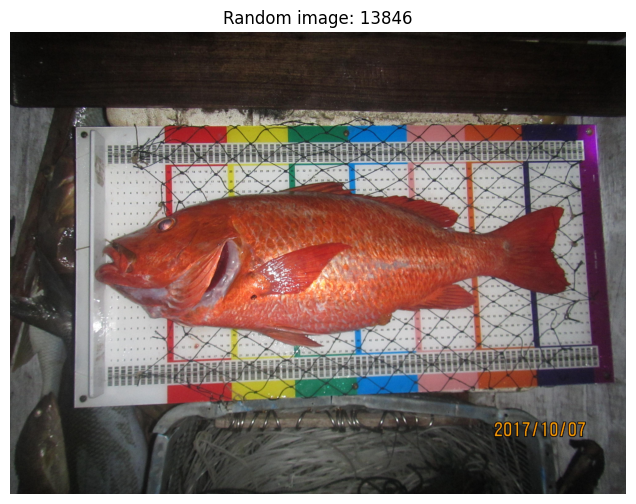

In [11]:
# Random image (train split)
rng = random.Random(42)
train_paths = discover_image_paths(cfg, "train")
path = rng.choice(train_paths)
sample = load_sample(path, split="train")

fig, ax = plt.subplots(figsize=(10, 6))
ax.imshow(cv2.cvtColor(sample.image, cv2.COLOR_BGR2RGB))
ax.set_title(f"Random image: {sample.image_id}")
ax.axis("off")
plt.show()


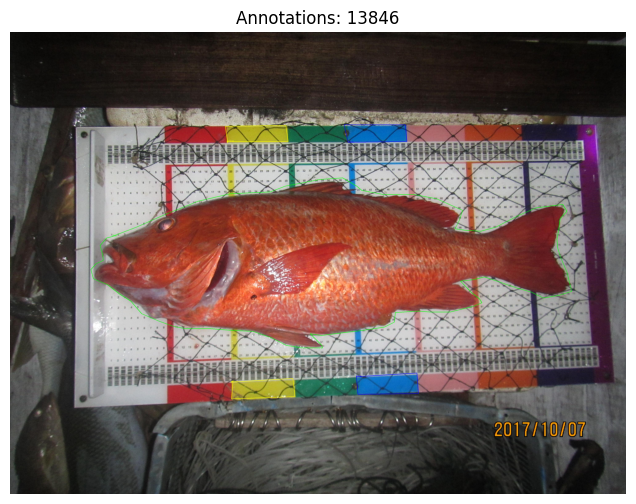

Annotation counts by class: {'fish': 1, 'yellow': 2, 'blue': 2}


In [12]:
# Polygons overlaid
poly_vis = draw_polygon_annotations(sample)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(poly_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Annotations: {sample.image_id}")
plt.axis("off")
plt.show()

class_counts = Counter(a.class_name for a in sample.annotations)
print("Annotation counts by class:", dict(class_counts))


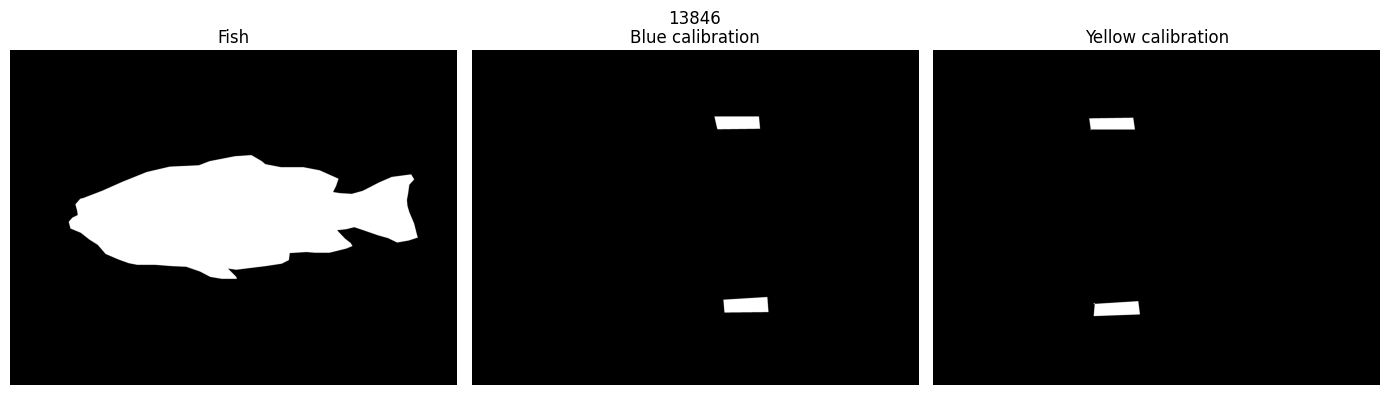

In [13]:
# Per-class masks
h, w = sample.height, sample.width
fish_mask = mask_from_class(sample.annotations, "fish", h, w)
blue_mask = mask_from_class(sample.annotations, "blue", h, w)
yellow_mask = mask_from_class(sample.annotations, "yellow", h, w)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, mask, title in zip(
    axes,
    [fish_mask, blue_mask, yellow_mask],
    ["Fish", "Blue calibration", "Yellow calibration"],
):
    ax.imshow(mask, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
fig.suptitle(sample.image_id)
plt.tight_layout()
plt.show()


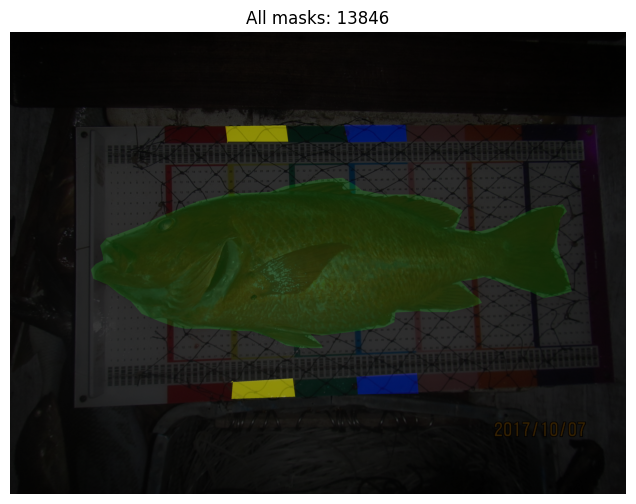

In [14]:
# Combined mask overlay on image
mask_vis = overlay_masks(sample)
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(mask_vis, cv2.COLOR_BGR2RGB))
plt.title(f"All masks: {sample.image_id}")
plt.axis("off")
plt.show()


## Length in pixels (bbox vs PCA)

Visual check before mm calibration — PCA axis drawn on the fish mask.


bbox length: 3124.0 px
PCA length:  3115.2 px


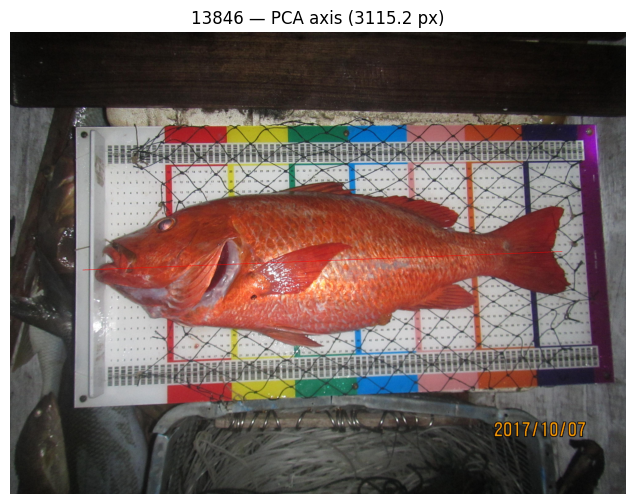

2026-05-29 20:49:09 | INFO     | src.visualization | Saved figure: /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/outputs/figures/exploration_pca_axis.png
Saved: /Users/sebastianinouye/Desktop/Everything/Projects/Github/fishnet_cv/outputs/figures/exploration_pca_axis.png


In [15]:
bbox_px = measure_bbox_length(fish_mask)
pca_px, center, axis = measure_pca_length(fish_mask)
print(f"bbox length: {bbox_px:.1f} px")
print(f"PCA length:  {pca_px:.1f} px")

fig = plot_pca_axis(sample.image, fish_mask, title=f"{sample.image_id} — PCA axis")
plt.show()

# Save example figure for reports
cfg.ensure_output_dirs()
out = cfg.outputs_figures / "exploration_pca_axis.png"
save_figure(fig, out)
print("Saved:", out)
